In [ ]:
# NCrystal notebook settings
# title: NCrystal materials in OpenMC
# shortkey: nd25openmc
# section: nd2025
# requires: plot, utils, openmc
# slow: yes

In this notebook we show how to use NCrystal materials in OpenMC.

Download nuclear data library needed by OpenMC (this is not related to NCrystal):

In [ ]:
from ncrystal_notebook_utilities.openmc import download_and_prepare_nndc_data
openmc_xsfile = download_and_prepare_nndc_data()

In [ ]:
import numpy as np
import openmc
openmc.config['cross_sections'] = str(openmc_xsfile)

## Example: create an OpenMC material from NCrystal and plot the XS

In [ ]:
m = openmc.Material.from_ncrystal('Al4C3_sg166_AluminiumCarbide.ncmat')
m.name = 'Aluminum Carbide'
print(m)
_ = openmc.plot_xs({m:['total']})

We can also do this with a multiphase material. With NCrystal materials we do not have the limitation of only one S(a,b) treatment applied for each nuclide, like it happens with ACE files:

In [ ]:
m = openmc.Material.from_ncrystal('phases<0.4*Al2O3_sg167_Corundum.ncmat&'
                                  '0.2*Al4C3_sg166_AluminiumCarbide.ncmat&'
                                  '0.2*AlN_sg186_AluminumNitride.ncmat&'
                                  '0.2*Al_sg225.ncmat>;temp=296K')
print(m)
m.name = '40% Al2O3 + 20% Al4C3 + 20% AlN + 20% Al'
_ = openmc.plot_xs({m:['total']})

## Example: Create a simple simulation in OpenMC

In [ ]:
m = openmc.Material.from_ncrystal('Al_sg225.ncmat')
s = openmc.Sphere(r=10, boundary_type='vacuum')
c = openmc.Cell(region=-s, fill=m)
g = openmc.Geometry([c])
settings = openmc.Settings()
settings.source = openmc.IndependentSource()
settings.batches = 10
settings.particles = 100000
settings.run_mode = 'fixed source'
_ = openmc.Model(geometry=g, settings=settings).run()

## Example compute the diffraction pattern from a germanium single crystal

In this example we will simulate a beam of thermal neutrons incident on a cube of single crystal germanium. Downstream from the sample we will locate a 2D detector to compute the diffraction pattern.

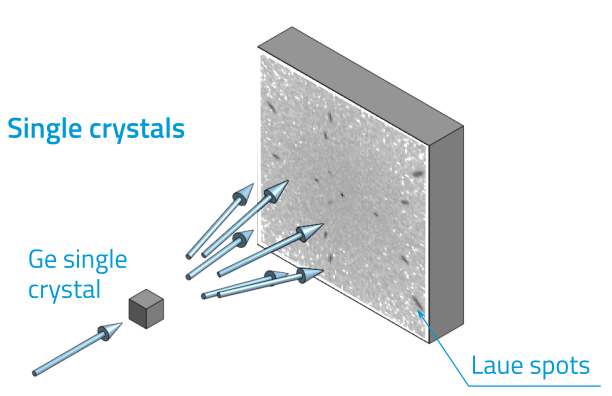

In [ ]:

def compute_diffraction_pattern(m):
  side = 2 # cm
  s1 = openmc.model.OrthogonalBox([-side/2,-side/2,-side/2],
                                  [2*side/2, 0, 0],
                                  [0, 2*side/2, 0],
                                  [0, 0, 2*side/2])
  s99 = openmc.Sphere(r=1000*side/2, boundary_type='vacuum')
  c1 = openmc.Cell(region=-s1, fill=m)
  c99 = openmc.Cell(region=+s1&-s99, fill=None)
  g = openmc.Geometry([c1, c99])

  settings = openmc.Settings()
  source = openmc.IndependentSource()
  source.space = openmc.stats.Point((0,0,-50*side/2))
  source.energy = openmc.stats.Uniform(a=0.001, b=0.1)
  source.angle = openmc.stats.Monodirectional(reference_uvw=[0,0,1])
  settings.source = source
  settings.batches = 10
  settings.particles = 100000
  settings.run_mode = 'fixed source'

  tal1 = openmc.Tally(name='2D detector')
  msh1 = openmc.RectilinearMesh()
  msh1.x_grid=np.linspace(-50*side, 50*side, 100)
  msh1.y_grid=np.linspace(-50*side, 50*side, 100)
  msh1.z_grid=[25*side, 25*side+1]
  tal1.filters = [openmc.MeshFilter(msh1)]
  tal1.scores = ['flux']

  tallies = openmc.Tallies([tal1])
  !rm summary.h5 statepoint.10.h5
  openmc.Model(geometry=g, settings=settings, tallies=tallies).run()

def plot_diffraction_pattern():
  df = openmc.StatePoint('statepoint.10.h5').get_tally(name='2D detector').get_pandas_dataframe()
  phi = df['mean'].values
  phi.shape = (99,99)
  import matplotlib.pyplot as plt
  import matplotlib.colors
  plt.figure()
  plt.imshow(phi,norm=matplotlib.colors.LogNorm(), cmap='Greys')
  plt.axis('off')

In [ ]:
cfg = 'Ge_sg227.ncmat;mos=20.0arcmin;dir1=@crys_hkl:5,1,1@lab:0,0,1;dir2=@crys_hkl:0,-1,1@lab:0,1,0'
m = openmc.Material.from_ncrystal(cfg)

compute_diffraction_pattern(m)
plot_diffraction_pattern()

We can repeat the simulation without the configuration string parameters that give the orientation of the crystal. NCrystal understands then as a polycrystalline material (under the powder approximation) and we will rings the Debye-Scherrer that are a result of powder diffraction.

In [ ]:
cfg = 'Ge_sg227.ncmat'
m = openmc.Material.from_ncrystal(cfg)

compute_diffraction_pattern(m)
plot_diffraction_pattern()